In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data generation
from src.data_generation.realistic_world import simulate_realistic_world

# Training utilities
from src.training.preprocessing import split_data, scale_data
from src.training.train_lr import train_logistic_regression
from src.training.train_mlp import train_mlp_model, plot

# Fairness metrics
from src.metrics.fairness import fairness_by_group, equal_opportunity_diff


In [144]:
df = simulate_realistic_world(10000)

df.head()


,race,gender,age,ses,bmi,glucose_measured,hba1c_measured,diabetes_true,diabetes_label
0,0,1,46.217957,0.749936,26.378682,99.618088,4.709433,0,0
1,0,1,59.455714,0.627074,24.291773,87.149496,4.954423,0,0
2,0,0,73.455289,0.558701,28.830401,88.122016,5.752754,0,0
3,2,0,51.737807,-0.973943,29.255057,81.450118,6.236445,1,1
4,1,1,63.090423,0.130823,29.303944,108.085617,5.723280,0,0


In [145]:
features = ["glucose_measured", "hba1c_measured", "age", "bmi"]
target = "diabetes_label"

X_train, X_test, y_train, y_test = split_data(df, features, target)

X_train_s, X_test_s, scaler = scale_data(X_train, X_test)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Train prevalence:", y_train.mean())
print("Test prevalence:", y_test.mean())


Train size: 8000
Test size: 2000
Train prevalence: 0.293375
Test prevalence: 0.286


In [146]:
lr_results = train_logistic_regression(
    X_train_s, y_train,
    X_test_s, y_test
)

print("LR Accuracy:", lr_results["accuracy"])
print("LR AUROC:", lr_results["AUROC"])


LR Accuracy: 0.7175
LR AUROC: 0.6572753227164991


Epoch 1/20: train_loss=0.5752, train_acc=71.53, val_loss=0.5680, val_acc=71.80
Epoch 2/20: train_loss=0.5653, train_acc=72.17, val_loss=0.5678, val_acc=71.80
Epoch 3/20: train_loss=0.5645, train_acc=72.17, val_loss=0.5685, val_acc=72.00
Epoch 4/20: train_loss=0.5633, train_acc=72.29, val_loss=0.5670, val_acc=71.90
Epoch 5/20: train_loss=0.5634, train_acc=72.11, val_loss=0.5678, val_acc=71.80
Epoch 6/20: train_loss=0.5629, train_acc=72.12, val_loss=0.5693, val_acc=71.30
Epoch 7/20: train_loss=0.5628, train_acc=72.38, val_loss=0.5690, val_acc=71.15
Epoch 8/20: train_loss=0.5631, train_acc=72.12, val_loss=0.5688, val_acc=71.25
Epoch 9/20: train_loss=0.5623, train_acc=72.21, val_loss=0.5686, val_acc=72.15
Epoch 10/20: train_loss=0.5629, train_acc=72.21, val_loss=0.5678, val_acc=71.60
Epoch 11/20: train_loss=0.5623, train_acc=72.30, val_loss=0.5705, val_acc=71.30
Epoch 12/20: train_loss=0.5620, train_acc=72.09, val_loss=0.5705, val_acc=71.05
Epoch 13/20: train_loss=0.5624, train_acc=72.31, 

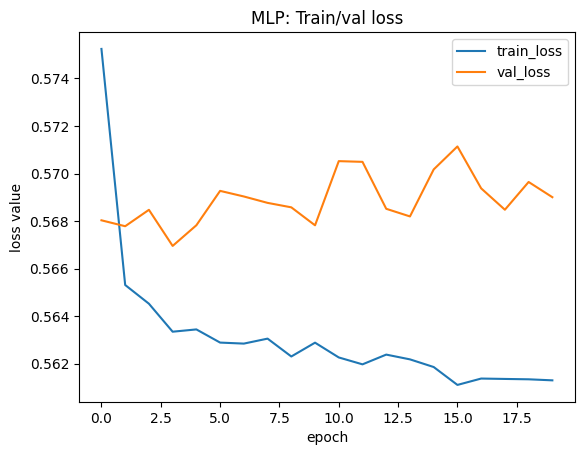

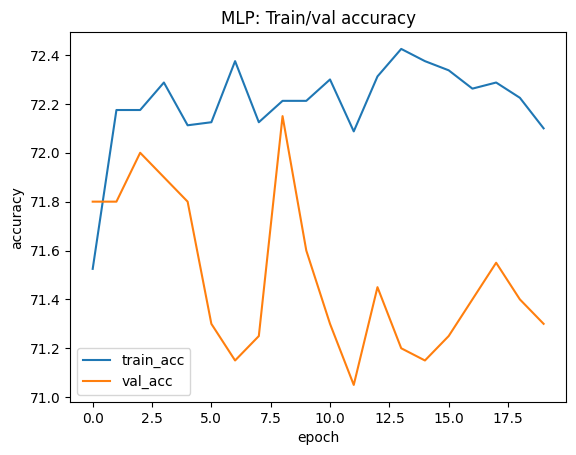

In [147]:
mlp_results = train_mlp_model(
    X_train_s, y_train,
    X_test_s, y_test,
    input_dim=len(features),
    hidden_dim=32,
    n_epochs=20,
    lr=0.001
)

print("MLP Accuracy:", mlp_results["accuracy"])
print("MLP AUROC:", mlp_results["AUROC"])


In [148]:
race_test = df.loc[X_test.index, "race"]
gender_test = df.loc[X_test.index, "gender"]

# ----------------------
# LR Fairness
# ----------------------
print("=== LR Fairness by Race ===")
lr_fair_race = fairness_by_group(y_test, lr_results["pred"], race_test)
print(lr_fair_race)

print("\n=== LR Fairness by Gender ===")
lr_fair_gender = fairness_by_group(y_test, lr_results["pred"], gender_test)
print(lr_fair_gender)

LR_EO_race   = equal_opportunity_diff(lr_fair_race)
LR_EO_gender = equal_opportunity_diff(lr_fair_gender)

# ----------------------
# MLP Fairness
# ----------------------
print("\n=== MLP Fairness by Race ===")
mlp_fair_race = fairness_by_group(y_test, mlp_results["pred"], race_test)
print(mlp_fair_race)

print("\n=== MLP Fairness by Gender ===")
mlp_fair_gender = fairness_by_group(y_test, mlp_results["pred"], gender_test)
print(mlp_fair_gender)

MLP_EO_race   = equal_opportunity_diff(mlp_fair_race)
MLP_EO_gender = equal_opportunity_diff(mlp_fair_gender)


=== LR Fairness by Race ===
        FPR       FNR       TPR       TNR
0  0.039352  0.899696  0.100304  0.960648
1  0.069069  0.778481  0.221519  0.930931
2  0.034632  0.952941  0.047059  0.965368

=== LR Fairness by Gender ===
        FPR       FNR       TPR       TNR
0  0.058074  0.868657  0.131343  0.941926
1  0.033241  0.881857  0.118143  0.966759

=== MLP Fairness by Race ===
        FPR       FNR       TPR       TNR
0  0.060185  0.872340  0.127660  0.939815
1  0.090090  0.740506  0.259494  0.909910
2  0.034632  0.941176  0.058824  0.965368

=== MLP Fairness by Gender ===
        FPR       FNR       TPR       TNR
0  0.069405  0.856716  0.143284  0.930595
1  0.056787  0.831224  0.168776  0.943213


In [150]:
results_realistic = {
    "world_name": "Realistic",
    "LR_accuracy": lr_results["accuracy"],
    "LR_AUROC": lr_results["AUROC"],
    "LR_EO_race": LR_EO_race,
    "LR_EO_gender": LR_EO_gender,

    "MLP_accuracy": mlp_results["accuracy"],
    "MLP_AUROC": mlp_results["AUROC"],
    "MLP_EO_race": MLP_EO_race,
    "MLP_EO_gender": MLP_EO_gender,
}

results_realistic


{'world_name': 'Realistic',
 'LR_accuracy': 0.7175,
 'LR_AUROC': 0.6572753227164991,
 'LR_EO_race': 0.17446016381236037,
 'LR_EO_gender': 0.013199823666477734,
 'MLP_accuracy': np.float64(0.713),
 'MLP_AUROC': 0.6534164365046718,
 'MLP_EO_race': 0.20067014147431123,
 'MLP_EO_gender': 0.025492789218464623}

In [151]:
def threshold_sweep(y_true, probs, group, n=50):
    """
    Sweeps thresholds and computes EO for each threshold.
    """
    thresholds = np.linspace(0.1, 0.9, n)
    eo_values = []

    for t in thresholds:
        pred = (probs > t).astype(int)
        fair_df = fairness_by_group(y_true, pred, group)
        eo_values.append(equal_opportunity_diff(fair_df))

    return thresholds, np.array(eo_values)


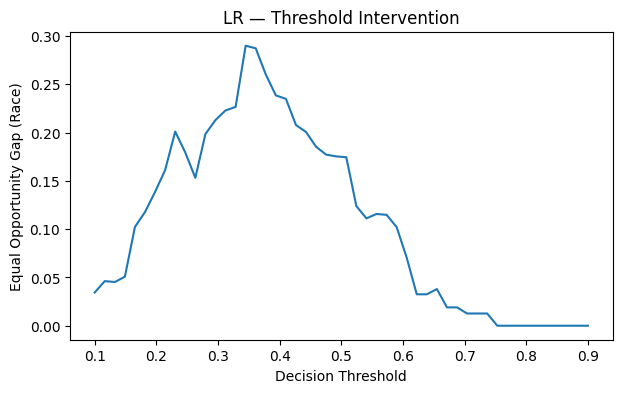

(np.float64(0.753061224489796), np.float64(0.0))

In [152]:
t_lr, eo_lr = threshold_sweep(
    y_test.values,
    lr_results["probs"],
    race_test
)

plt.figure(figsize=(7,4))
plt.plot(t_lr, eo_lr)
plt.xlabel("Decision Threshold")
plt.ylabel("Equal Opportunity Gap (Race)")
plt.title("LR — Threshold Intervention")
plt.show()

best_t_lr = t_lr[np.argmin(eo_lr)]
best_eo_lr = eo_lr.min()

best_t_lr, best_eo_lr


In [153]:
lr_pred_adj = (lr_results["probs"] > best_t_lr).astype(int)

lr_adj_race   = fairness_by_group(y_test, lr_pred_adj, race_test)
lr_adj_gender = fairness_by_group(y_test, lr_pred_adj, gender_test)

print("=== LR Adjusted Fairness — Race ===")
display(lr_adj_race)

print("=== LR Adjusted Fairness — Gender ===")
display(lr_adj_gender)


=== LR Adjusted Fairness — Race ===


,FPR,FNR,TPR,TNR
0,0.0,1.0,0.0,1.0
1,0.0,1.0,0.0,1.0
2,0.0,1.0,0.0,1.0


=== LR Adjusted Fairness — Gender ===


,FPR,FNR,TPR,TNR
0,0.0,1.0,0.0,1.0
1,0.0,1.0,0.0,1.0


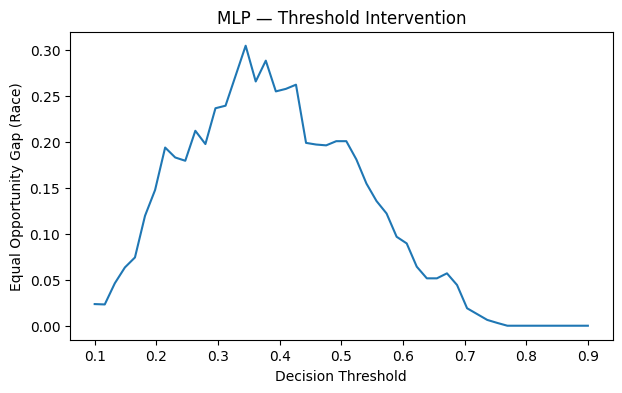

np.float64(0.7693877551020408)

In [154]:
t_mlp, eo_mlp = threshold_sweep(
    y_test.values,
    mlp_results["probs"],
    race_test
)

plt.figure(figsize=(7,4))
plt.plot(t_mlp, eo_mlp)
plt.xlabel("Decision Threshold")
plt.ylabel("Equal Opportunity Gap (Race)")
plt.title("MLP — Threshold Intervention")
plt.show()

best_t_mlp = t_mlp[np.argmin(eo_mlp)]
best_t_mlp


In [155]:
mlp_pred_adj = (mlp_results["probs"] > best_t_mlp).astype(int)

mlp_adj_race   = fairness_by_group(y_test, mlp_pred_adj, race_test)
mlp_adj_gender = fairness_by_group(y_test, mlp_pred_adj, gender_test)

print("=== MLP Adjusted Fairness — Race ===")
display(mlp_adj_race)

print("=== MLP Adjusted Fairness — Gender ===")
display(mlp_adj_gender)


=== MLP Adjusted Fairness — Race ===


,FPR,FNR,TPR,TNR
0,0.0,1.0,0.0,1.0
1,0.0,1.0,0.0,1.0
2,0.0,1.0,0.0,1.0


=== MLP Adjusted Fairness — Gender ===


,FPR,FNR,TPR,TNR
0,0.0,1.0,0.0,1.0
1,0.0,1.0,0.0,1.0


In [156]:
intervention_summary = {
    "LR_EO_before": LR_EO_race,
    "LR_EO_after": equal_opportunity_diff(lr_adj_race),
    "MLP_EO_before": MLP_EO_race,
    "MLP_EO_after": equal_opportunity_diff(mlp_adj_race)
}

intervention_summary


{'LR_EO_before': 0.17446016381236037,
 'LR_EO_after': 0.0,
 'MLP_EO_before': 0.20067014147431123,
 'MLP_EO_after': 0.0}

In [157]:
acc_before = accuracy_score(y_test, mlp_results["pred"])
acc_after  = accuracy_score(y_test, mlp_pred_adj)

acc_before, acc_after


(0.713, 0.714)

In [158]:
df["race_gender"] = df["race"].astype(str) + "_" + df["gender"].astype(str)
race_gender_test = df.loc[X_test.index, "race_gender"]
df["race_gender"].value_counts()


race_gender
0_1    2989
0_0    2957
1_0    1269
1_1    1255
2_1     777
2_0     753
Name: count, dtype: int64

In [159]:
print("=== LR Intersectional Fairness (Race × Gender) ===")
lr_fair_rg = fairness_by_group(y_test, lr_results["pred"], race_gender_test)
display(lr_fair_rg)

LR_EO_rg = equal_opportunity_diff(lr_fair_rg)
print("\nLR EO (Race×Gender):", LR_EO_rg)


=== LR Intersectional Fairness (Race × Gender) ===


,FPR,FNR,TPR,TNR
0_0,0.051887,0.888889,0.111111,0.948113
0_1,0.027273,0.914286,0.085714,0.972727
1_0,0.084337,0.791667,0.208333,0.915663
1_1,0.053892,0.758065,0.241935,0.946108
2_0,0.043103,0.940000,0.060000,0.956897
2_1,0.026087,0.971429,0.028571,0.973913



LR EO (Race×Gender): 0.21336405529953917


In [160]:
print("=== MLP Intersectional Fairness (Race × Gender) ===")
mlp_fair_rg = fairness_by_group(y_test, mlp_results["pred"], race_gender_test)
display(mlp_fair_rg)

MLP_EO_rg = equal_opportunity_diff(mlp_fair_rg)
print("\nMLP EO (Race×Gender):", MLP_EO_rg)


=== MLP Intersectional Fairness (Race × Gender) ===


,FPR,FNR,TPR,TNR
0_0,0.068396,0.883598,0.116402,0.931604
0_1,0.052273,0.857143,0.142857,0.947727
1_0,0.102410,0.760417,0.239583,0.897590
1_1,0.077844,0.709677,0.290323,0.922156
2_0,0.025862,0.940000,0.060000,0.974138
2_1,0.043478,0.942857,0.057143,0.956522



MLP EO (Race×Gender): 0.23317972350230418
